In [216]:
import pandas as pd

In [217]:
df=pd.read_csv('dataset.csv')

In [218]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [219]:
df['market_id']=df['market_id'].fillna(0).astype(int)

In [220]:
df['market_id'].isnull().sum()

np.int64(0)

In [221]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

df['delivery_time'] = df['actual_delivery_time'] - df['created_at']

In [222]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time
0,1,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,0 days 01:02:59
1,2,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,0 days 01:07:04
2,3,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,0 days 00:29:41
3,3,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,0 days 00:51:15
4,3,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,0 days 00:39:50


In [223]:
df.drop(['created_at','actual_delivery_time'],axis=1,inplace=True)

In [224]:
df['delivery_time'].isnull().sum()

np.int64(7)

In [225]:
df.dropna(subset=['delivery_time'], inplace=True)

In [226]:
df['delivery_time'] = (df['delivery_time'].dt.total_seconds() / 60).round().astype(int)

In [227]:
df.drop(columns=['store_id'],inplace=True)

In [228]:
df.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time
0,1,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,63
1,2,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67
2,3,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,30
3,3,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,51
4,3,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,40


In [229]:
df.info()

<class 'pandas.DataFrame'>
Index: 197421 entries, 0 to 197427
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 197421 non-null  int64  
 1   store_primary_category    192661 non-null  str    
 2   order_protocol            196426 non-null  float64
 3   total_items               197421 non-null  int64  
 4   subtotal                  197421 non-null  int64  
 5   num_distinct_items        197421 non-null  int64  
 6   min_item_price            197421 non-null  int64  
 7   max_item_price            197421 non-null  int64  
 8   total_onshift_partners    181159 non-null  float64
 9   total_busy_partners       181159 non-null  float64
 10  total_outstanding_orders  181159 non-null  float64
 11  delivery_time             197421 non-null  int64  
dtypes: float64(4), int64(7), str(1)
memory usage: 19.6 MB


In [230]:
df['store_primary_category'].isnull().sum()

np.int64(4760)

In [231]:
df['store_primary_category'] = df['store_primary_category'].fillna('unknown')

In [232]:
import sklearn

from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False, handle_unknown='ignore')

category_encoded=ohe.fit_transform(df[['store_primary_category']])

In [233]:
df.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time
0,1,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,63
1,2,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,67
2,3,unknown,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,30
3,3,unknown,1.0,6,6900,5,600,1800,1.0,1.0,2.0,51
4,3,unknown,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,40


In [234]:
category_df = pd.DataFrame(
    category_encoded,
    columns=ohe.get_feature_names_out(['store_primary_category']),
    index=df.index
)

In [235]:
df=pd.concat([df,category_df],axis=1)

In [236]:
df.head()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,...,store_primary_category_spanish,store_primary_category_steak,store_primary_category_sushi,store_primary_category_tapas,store_primary_category_thai,store_primary_category_turkish,store_primary_category_unknown,store_primary_category_vegan,store_primary_category_vegetarian,store_primary_category_vietnamese
0,1,american,1.0,4,3441,4,557,1239,33.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,unknown,1.0,1,1900,1,1900,1900,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3,unknown,1.0,6,6900,5,600,1800,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,3,unknown,1.0,3,3900,3,1100,1600,6.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [237]:
df.drop(columns=['store_primary_category'],inplace=True)

In [238]:
cols = [col for col in df.columns if col.startswith('store_primary_category_')]

df[cols] = df[cols].astype(int)

In [239]:
df.info()

<class 'pandas.DataFrame'>
Index: 197421 entries, 0 to 197427
Data columns (total 86 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   market_id                                 197421 non-null  int64  
 1   order_protocol                            196426 non-null  float64
 2   total_items                               197421 non-null  int64  
 3   subtotal                                  197421 non-null  int64  
 4   num_distinct_items                        197421 non-null  int64  
 5   min_item_price                            197421 non-null  int64  
 6   max_item_price                            197421 non-null  int64  
 7   total_onshift_partners                    181159 non-null  float64
 8   total_busy_partners                       181159 non-null  float64
 9   total_outstanding_orders                  181159 non-null  float64
 10  delivery_time                       

In [240]:
df.head()

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,...,store_primary_category_spanish,store_primary_category_steak,store_primary_category_sushi,store_primary_category_tapas,store_primary_category_thai,store_primary_category_turkish,store_primary_category_unknown,store_primary_category_vegan,store_primary_category_vegetarian,store_primary_category_vietnamese
0,1,1.0,4,3441,4,557,1239,33.0,14.0,21.0,...,0,0,0,0,0,0,0,0,0,0
1,2,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,0
2,3,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
3,3,1.0,6,6900,5,600,1800,1.0,1.0,2.0,...,0,0,0,0,0,0,1,0,0,0
4,3,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,...,0,0,0,0,0,0,1,0,0,0


In [241]:
df['total_onshift_partners'].isnull().sum()

np.int64(16262)

In [242]:
df['total_onshift_partners'] = df['total_onshift_partners'].fillna(0).astype(int)
df['total_busy_partners'] = df['total_busy_partners'].fillna(0).astype(int)

In [243]:
df.info()

<class 'pandas.DataFrame'>
Index: 197421 entries, 0 to 197427
Data columns (total 86 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   market_id                                 197421 non-null  int64  
 1   order_protocol                            196426 non-null  float64
 2   total_items                               197421 non-null  int64  
 3   subtotal                                  197421 non-null  int64  
 4   num_distinct_items                        197421 non-null  int64  
 5   min_item_price                            197421 non-null  int64  
 6   max_item_price                            197421 non-null  int64  
 7   total_onshift_partners                    197421 non-null  int64  
 8   total_busy_partners                       197421 non-null  int64  
 9   total_outstanding_orders                  181159 non-null  float64
 10  delivery_time                       

In [244]:
df['total_outstanding_orders'] = df['total_outstanding_orders'].fillna(0).astype(int)

In [245]:
df['order_protocol'].unique()

array([ 1.,  2.,  3.,  4., nan,  5.,  6.,  7.])

In [246]:
df['order_protocol'] = df['order_protocol'].fillna(0).astype(int)

In [247]:
df.info()

<class 'pandas.DataFrame'>
Index: 197421 entries, 0 to 197427
Data columns (total 86 columns):
 #   Column                                    Non-Null Count   Dtype
---  ------                                    --------------   -----
 0   market_id                                 197421 non-null  int64
 1   order_protocol                            197421 non-null  int64
 2   total_items                               197421 non-null  int64
 3   subtotal                                  197421 non-null  int64
 4   num_distinct_items                        197421 non-null  int64
 5   min_item_price                            197421 non-null  int64
 6   max_item_price                            197421 non-null  int64
 7   total_onshift_partners                    197421 non-null  int64
 8   total_busy_partners                       197421 non-null  int64
 9   total_outstanding_orders                  197421 non-null  int64
 10  delivery_time                             197421 non-null  i

In [281]:
(df['delivery_time'] > 180).sum()

np.int64(0)

### So there are 138 rows which have delievery time greater than 180 minutes which are making our MSE extremely large so we will delete them

In [282]:
df = df[df['delivery_time'] <= 180].copy()

In [283]:
x = df.drop(columns=['delivery_time'])
y = df['delivery_time']

In [284]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [302]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [286]:
from tensorflow.keras.models import Sequential      #For sequential network
from tensorflow.keras.layers import Dense,Input           #for making the number of neuron layers
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [287]:
# Build our ANN Model

model=Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),    #First hidden layer connected with input layer
    Dense(32,activation='relu'),     #Second hidden layer
    Dense(16,activation='relu'),
    Dense(1)   #output layer
])

import tensorflow

opt=tensorflow.keras.optimizers.Adam(learning_rate=0.001)
loss=tensorflow.keras.losses.MeanSquaredError()

model.compile(optimizer=opt,loss=loss,metrics=['mae'])

In [288]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,889 (85.50 KB)

 Trainable params: 21,889 (85.50 KB)

 Non-trainable params: 0 (0.00 B)

In [289]:
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)

In [290]:
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
log_dir = "logs/fits/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorflow_callback=TensorBoard(log_dir=log_dir,histogram_freq=1)

In [295]:
import tensorflow
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=100,
                  callbacks=[tensorflow_callback,early_stopping_callback],batch_size=128,verbose=1
                )

Epoch 1/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step - loss: 237.1893 - mae: 11.3480 - val_loss: 245.4388 - val_mae: 11.5470
Epoch 2/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 1s 622us/step - loss: 236.9561 - mae: 11.3473 - val_loss: 244.8771 - val_mae: 11.4435
Epoch 3/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - loss: 237.1974 - mae: 11.3532 - val_loss: 247.2174 - val_mae: 11.7020
Epoch 4/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - loss: 237.2674 - mae: 11.3558 - val_loss: 244.7776 - val_mae: 11.3851
Epoch 5/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - loss: 236.9754 - mae: 11.3434 - val_loss: 246.0672 - val_mae: 11.5737
Epoch 6/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 1s 614us/step - loss: 236.7588 - mae: 11.3447 - val_loss: 245.3804 - val_mae: 11.4775
Epoch 7/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step - loss: 236.5364 - mae: 11.3343 - val_loss: 245.8326 - val_mae: 11.4206
Epoch 8/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 1s 613us/step - loss: 236.7878 - mae: 11.3386 - val_lo

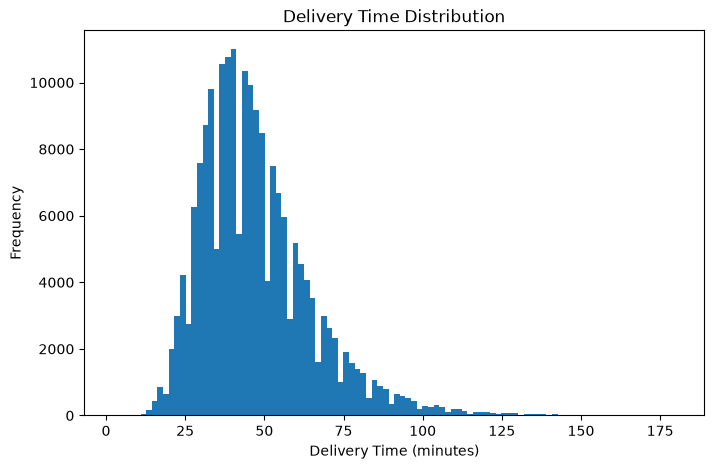

In [296]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['delivery_time'], bins=100)
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.title('Delivery Time Distribution')
plt.show()

In [297]:
y_pred=model.predict(x_test)

1234/1234 ━━━━━━━━━━━━━━━━━━━━ 0s 172us/step


In [298]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 11.477402687072754
RMSE: 15.633578211663359
R² Score: 0.24277156591415405


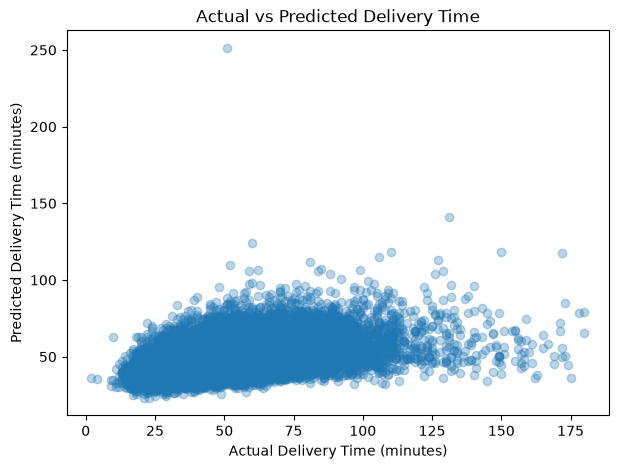

In [299]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

In [300]:
print(x.shape)
print(x.columns.tolist())

(197283, 85)
['market_id', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders', 'store_primary_category_afghan', 'store_primary_category_african', 'store_primary_category_alcohol', 'store_primary_category_alcohol-plus-food', 'store_primary_category_american', 'store_primary_category_argentine', 'store_primary_category_asian', 'store_primary_category_barbecue', 'store_primary_category_belgian', 'store_primary_category_brazilian', 'store_primary_category_breakfast', 'store_primary_category_british', 'store_primary_category_bubble-tea', 'store_primary_category_burger', 'store_primary_category_burmese', 'store_primary_category_cafe', 'store_primary_category_cajun', 'store_primary_category_caribbean', 'store_primary_category_catering', 'store_primary_category_cheese', 'store_primary_category_chinese', 'store_primary_category_chocolate', 'store_primary_category_comfo